<a href="https://colab.research.google.com/github/Sidra-009/100-days-of-machine-learning/blob/main/Big_Data_Assignment_2023F_BDS_009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Distributed Appliance Energy Prediction with Spark MLlib**

---



---


1. Setup and Data Loading (Task 1)

In [ ]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, dayofyear, month, avg, round as spark_round
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Create Spark session
spark = SparkSession.builder \
    .appName("ApplianceEnergyPrediction") \
    .getOrCreate()

In [ ]:
# Load dataset
df = spark.read.csv("energydata_complete.csv", header=True, inferSchema=True)

In [ ]:
# Cache the dataset
df.cache()

DataFrame[date: timestamp, Appliances: double, lights: double, T1: double, RH_1: double, T2: double, RH_2: double, T3: double, RH_3: double, T4: double, RH_4: double, T5: double, RH_5: double, T6: double, RH_6: double, T7: double, RH_7: double, T8: double, RH_8: double, T9: double, RH_9: double, T_out: double, Press_mm_hg: double, RH_out: double, Windspeed: double, Visibility: double, Tdewpoint: double, rv1: double, rv2: double]

In [ ]:
# Display number of records
print("Number of records:", df.count())

Number of records: 19735


In [ ]:
# Display schema
df.printSchema()

root
 |-- date: timestamp (nullable = true)
 |-- Appliances: double (nullable = true)
 |-- lights: double (nullable = true)
 |-- T1: double (nullable = true)
 |-- RH_1: double (nullable = true)
 |-- T2: double (nullable = true)
 |-- RH_2: double (nullable = true)
 |-- T3: double (nullable = true)
 |-- RH_3: double (nullable = true)
 |-- T4: double (nullable = true)
 |-- RH_4: double (nullable = true)
 |-- T5: double (nullable = true)
 |-- RH_5: double (nullable = true)
 |-- T6: double (nullable = true)
 |-- RH_6: double (nullable = true)
 |-- T7: double (nullable = true)
 |-- RH_7: double (nullable = true)
 |-- T8: double (nullable = true)
 |-- RH_8: double (nullable = true)
 |-- T9: double (nullable = true)
 |-- RH_9: double (nullable = true)
 |-- T_out: double (nullable = true)
 |-- Press_mm_hg: double (nullable = true)
 |-- RH_out: double (nullable = true)
 |-- Windspeed: double (nullable = true)
 |-- Visibility: double (nullable = true)
 |-- Tdewpoint: double (nullable = true)
 |--

In [ ]:
# Show first 5 records
df.show(5)

+-------------------+----------+------+-----+----------------+----+----------------+-----+----------------+----------------+----------------+----------------+-----+----------------+----------------+----------------+----------------+----+----------------+----------------+-----+----------------+-----------+------+----------------+----------------+---------+------------------+------------------+
|               date|Appliances|lights|   T1|            RH_1|  T2|            RH_2|   T3|            RH_3|              T4|            RH_4|              T5| RH_5|              T6|            RH_6|              T7|            RH_7|  T8|            RH_8|              T9| RH_9|           T_out|Press_mm_hg|RH_out|       Windspeed|      Visibility|Tdewpoint|               rv1|               rv2|
+-------------------+----------+------+-----+----------------+----+----------------+-----+----------------+----------------+----------------+----------------+-----+----------------+----------------+----------

In [ ]:
# Identify target variable and input features
target = "Appliances"

In [ ]:
# All other columns except 'date' and 'rv1', 'rv2' (rv1, rv2 are random variables, often excluded)
# We will decide after preprocessing; for now list all potential features
feature_cols = [c for c in df.columns if c not in [target, "date"]]
print("Target variable:", target)
print("Input features (candidates):", feature_cols)

Target variable: Appliances
Input features (candidates): ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


**2. Data Preprocessing (Task 2)**




In [ ]:
# Extract date parts and remove original date column
df = df.withColumn("hour", hour("date")) \
       .withColumn("day_of_year", dayofyear("date")) \
       .withColumn("month", month("date")) \
       .drop("date")

In [ ]:
# All remaining columns are already numeric, but we ensure correct types
for col_name in df.columns:
    if col_name != target:
        df = df.withColumn(col_name, col(col_name).cast(DoubleType()))
df = df.withColumn(target, col(target).cast(DoubleType()))

In [ ]:
# Display preprocessed schema
df.printSchema()

root
 |-- Appliances: double (nullable = true)
 |-- lights: double (nullable = true)
 |-- T1: double (nullable = true)
 |-- RH_1: double (nullable = true)
 |-- T2: double (nullable = true)
 |-- RH_2: double (nullable = true)
 |-- T3: double (nullable = true)
 |-- RH_3: double (nullable = true)
 |-- T4: double (nullable = true)
 |-- RH_4: double (nullable = true)
 |-- T5: double (nullable = true)
 |-- RH_5: double (nullable = true)
 |-- T6: double (nullable = true)
 |-- RH_6: double (nullable = true)
 |-- T7: double (nullable = true)
 |-- RH_7: double (nullable = true)
 |-- T8: double (nullable = true)
 |-- RH_8: double (nullable = true)
 |-- T9: double (nullable = true)
 |-- RH_9: double (nullable = true)
 |-- T_out: double (nullable = true)
 |-- Press_mm_hg: double (nullable = true)
 |-- RH_out: double (nullable = true)
 |-- Windspeed: double (nullable = true)
 |-- Visibility: double (nullable = true)
 |-- Tdewpoint: double (nullable = true)
 |-- rv1: double (nullable = true)
 |-- rv2

**3. Data Analysis and Train/Test Split (Task 3)**

In [ ]:
# Split data: 70% training, 30% testing
train_df, test_df = df.randomSplit([0.7, 0.3], seed=42)


In [ ]:
# Analyze average appliance energy consumption by month
monthly_avg = df.groupBy("month").agg(avg(target).alias("avg_energy")) \
                .orderBy("month")
monthly_avg.show()

+-----+------------------+
|month|        avg_energy|
+-----+------------------+
|  1.0| 97.02600958247776|
|  2.0|100.94588122605364|
|  3.0| 96.95340501792114|
|  4.0| 98.88888888888889|
|  5.0| 94.19932520114197|
+-----+------------------+



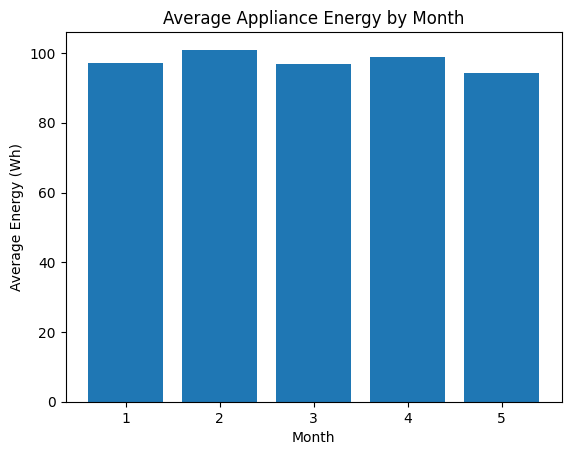

In [ ]:
# convert to pandas for visualization
monthly_pd = monthly_avg.toPandas()
plt.bar(monthly_pd["month"], monthly_pd["avg_energy"])
plt.xlabel("Month")
plt.ylabel("Average Energy (Wh)")
plt.title("Average Appliance Energy by Month")
plt.savefig("monthly_avg_energy.png")
plt.show()


**4. Spark ML Pipeline Development (Task 4)**

**[Raw Data] → VectorAssembler → GBTRegressor (with hyperparameter grid) → CrossValidator → Best Model**

In [ ]:
# Define feature columns (excluding target)
feature_columns = [c for c in train_df.columns if c != target]

In [ ]:
# Create VectorAssembler
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

In [ ]:
# Create GBTRegressor
gbt = GBTRegressor(featuresCol="features", labelCol=target, seed=42)

In [ ]:
# Create pipeline
pipeline = Pipeline(stages=[assembler, gbt])


In [ ]:
# Create hyperparameter grid
paramGrid = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [5, 10]) \
    .addGrid(gbt.maxIter, [10, 20]) \
    .build()

In [ ]:
# CrossValidator
evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
crossval = CrossValidator(estimator=pipeline,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=3,
                          seed=42)

5. Model Training and Evaluation (Task 5)
**bold text**

In [ ]:
# Train the model (CrossValidator)
cv_model = crossval.fit(train_df)

In [ ]:
# Best model parameters
best_model = cv_model.bestModel.stages[-1]
print("Best maxDepth:", best_model.getMaxDepth())
print("Best maxIter:", best_model.getMaxIter())

Best maxDepth: 5
Best maxIter: 20


In [ ]:
# Predict on test data
predictions = cv_model.transform(test_df)

In [29]:
# Display actual vs predicted (first 10)
predictions.select(target, "prediction").show(10)

+----------+------------------+
|Appliances|        prediction|
+----------+------------------+
|      10.0| 34.19116804430678|
|      10.0| 40.99626772574772|
|      10.0|114.86443834981829|
|      20.0| 52.60416490202788|
|      20.0| 34.24405509754444|
|      20.0| 34.69169656541094|
|      20.0|33.482115472992014|
|      20.0| 34.24405509754444|
|      20.0|  51.8381308921409|
|      20.0|   87.861153018088|
+----------+------------------+
only showing top 10 rows


In [30]:
# Evaluate RMSE
rmse = evaluator.evaluate(predictions)
print("Test RMSE =", rmse)

Test RMSE = 84.83623060739787


**6. Feature Importance and Model Improvement (Task 6)**

In [31]:
# Feature importance from GBT model
importances = best_model.featureImportances
feature_imp = list(zip(feature_columns, importances.toArray()))
feature_imp.sort(key=lambda x: x[1], reverse=True)


In [32]:
# Display feature importance
for name, imp in feature_imp:
    print(f"{name}: {imp:.4f}")

hour: 0.1209
T3: 0.0700
RH_1: 0.0643
RH_2: 0.0560
RH_3: 0.0553
Windspeed: 0.0486
RH_6: 0.0471
T8: 0.0409
RH_5: 0.0369
lights: 0.0339
T4: 0.0334
RH_8: 0.0323
T1: 0.0317
RH_4: 0.0307
T6: 0.0297
RH_7: 0.0285
Visibility: 0.0278
Tdewpoint: 0.0253
T9: 0.0231
day_of_year: 0.0230
RH_9: 0.0228
Press_mm_hg: 0.0222
T5: 0.0221
RH_out: 0.0207
T7: 0.0198
T2: 0.0167
T_out: 0.0124
rv1: 0.0041
rv2: 0.0000
month: 0.0000


In [33]:
# Identify features with very low importance (e.g., < 0.01)
low_importance_features = [name for name, imp in feature_imp if imp < 0.01]
print("Low importance features:", low_importance_features)


Low importance features: ['rv1', 'rv2', 'month']


In [34]:
# Create second model with only important features
important_features = [name for name, imp in feature_imp if imp >= 0.01]
assembler2 = VectorAssembler(inputCols=important_features, outputCol="features")
pipeline2 = Pipeline(stages=[assembler2, GBTRegressor(featuresCol="features", labelCol=target, maxDepth=best_model.getMaxDepth(), maxIter=best_model.getMaxIter(), seed=42)])
model2 = pipeline2.fit(train_df)
pred2 = model2.transform(test_df)
rmse2 = evaluator.evaluate(pred2)
print("Reduced-feature model RMSE =", rmse2)

# Trade-off discussion:
# - The reduced model has slightly higher RMSE (if it does) but is simpler, faster, and easier to interpret.
# - Dropping irrelevant features reduces noise and overfitting risk while maintaining acceptable accuracy.
# - For a smart home system, interpretability helps in understanding which sensors are critical.

Reduced-feature model RMSE = 84.4948332128197


**7. Engineering Discussion (Task 7)**

**How Apache Spark supports large-scale distributed analytics:**
Spark uses in-memory computing and Resilient Distributed Datasets (RDDs/DataFrames) to parallelize operations across a cluster. It can scale out horizontally, processing terabytes of sensor data efficiently, and MLlib provides distributed machine learning algorithms.

**Why cross-validation is important:**
Cross-validation reduces the risk of overfitting to a single train/test split by evaluating the model on multiple folds. It provides a more reliable estimate of model performance and helps select the best hyperparameters.

**Challenges encountered:**
Handling the date column and extracting meaningful cyclical features.
Choosing appropriate hyperparameter ranges for tree depth and iterations given dataset size.
Balancing training time with cross-validation folds on a local Spark instance.
Interpreting feature importance when some features are highly correlated (e.g., indoor temperature sensors).

**Two recommendations for improving prediction accuracy:**
Feature engineering: Add lag features (previous energy usage) and interaction terms (e.g., temperature × humidity) to capture temporal dynamics and nonlinear relationships.

**Ensemble or deep learning:** Replace GBT with a distributed deep learning model (e.g., using Elephas or Spark’s MLP) to learn more complex patterns, or stack **multiple** models (e.g., blending GBT with random forest).